In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("student_data.csv")
df.head()

,Student_ID,Gender,Attendance,Study_Hours,Assignment_Marks,Final_Marks,CGPA
0,S001,Female,92,5,88,90,9.0
1,S002,Male,85,4,80,82,8.2
2,S003,Female,78,3,72,75,7.5
3,S004,Male,65,2,60,62,6.2
4,S005,Female,95,6,92,94,9.4


In [5]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 15
Number of Columns: 7


In [6]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Student_ID', 'Gender', 'Attendance', 'Study_Hours', 'Assignment_Marks', 'Final_Marks', 'CGPA']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        15 non-null     object 
 1   Gender            15 non-null     object 
 2   Attendance        15 non-null     int64  
 3   Study_Hours       15 non-null     int64  
 4   Assignment_Marks  15 non-null     int64  
 5   Final_Marks       15 non-null     int64  
 6   CGPA              15 non-null     float64
dtypes: float64(1), int64(4), object(2)
memory usage: 972.0+ bytes


In [8]:
df.describe()

,Attendance,Study_Hours,Assignment_Marks,Final_Marks,CGPA
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,80.000000,3.666667,75.866667,78.133333,7.813333
std,12.989006,1.543033,13.860873,13.600770,1.360077
min,55.000000,1.000000,50.000000,52.000000,5.200000
25%,71.000000,2.500000,66.500000,69.000000,6.900000
50%,83.000000,4.000000,78.000000,81.000000,8.100000
75%,90.500000,5.000000,87.500000,89.500000,8.950000
max,96.000000,6.000000,94.000000,95.000000,9.500000


In [10]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Student_ID          0
Gender              0
Attendance          0
Study_Hours         0
Assignment_Marks    0
Final_Marks         0
CGPA                0
dtype: int64


In [11]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [13]:
for column in df.columns:
    print(column, ":", df[column].nunique())

Student_ID : 15
Gender : 2
Attendance : 15
Study_Hours : 6
Assignment_Marks : 15
Final_Marks : 15
CGPA : 15


In [14]:
print("Average Attendance:", df["Attendance"].mean())
print("Average Study Hours:", df["Study_Hours"].mean())
print("Average Assignment Marks:", df["Assignment_Marks"].mean())
print("Average Final Marks:", df["Final_Marks"].mean())
print("Average CGPA:", df["CGPA"].mean())

Average Attendance: 80.0
Average Study Hours: 3.6666666666666665
Average Assignment Marks: 75.86666666666666
Average Final Marks: 78.13333333333334
Average CGPA: 7.813333333333333


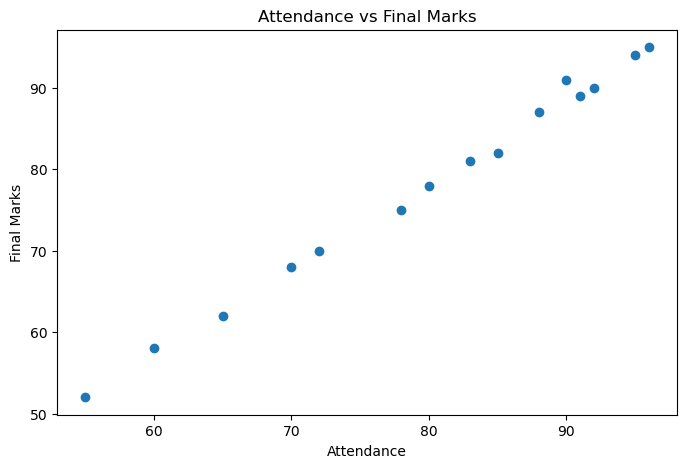

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(df["Attendance"], df["Final_Marks"])

plt.xlabel("Attendance")
plt.ylabel("Final Marks")
plt.title("Attendance vs Final Marks")

plt.show()

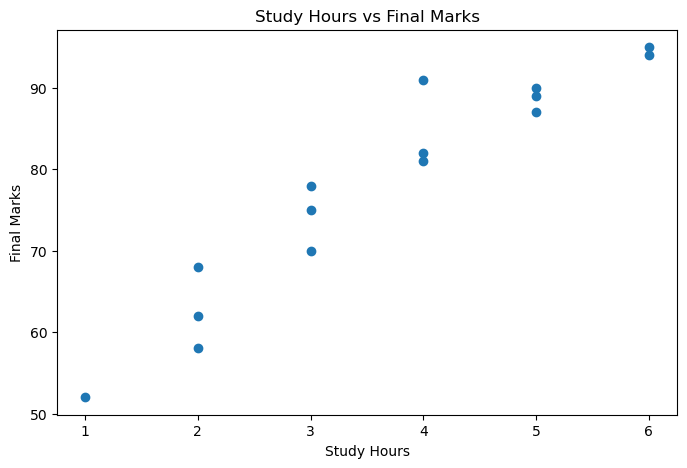

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(df["Study_Hours"], df["Final_Marks"])

plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")

plt.show()

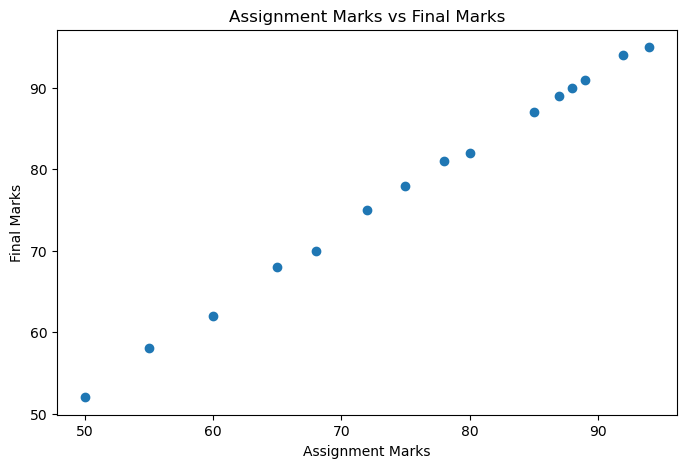

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(df["Assignment_Marks"], df["Final_Marks"])

plt.xlabel("Assignment Marks")
plt.ylabel("Final Marks")
plt.title("Assignment Marks vs Final Marks")

plt.show()

In [18]:
gender_performance = df.groupby("Gender")["Final_Marks"].mean()
print(gender_performance)

Gender
Female    84.375
Male      71.000
Name: Final_Marks, dtype: float64


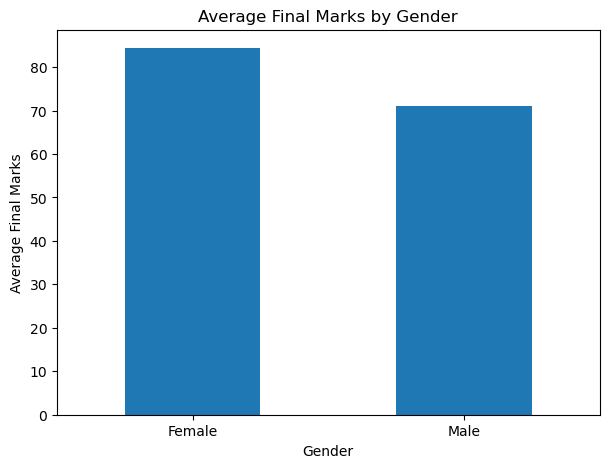

In [19]:
plt.figure(figsize=(7,5))

gender_performance.plot(kind="bar")

plt.title("Average Final Marks by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Final Marks")
plt.xticks(rotation=0)

plt.show()

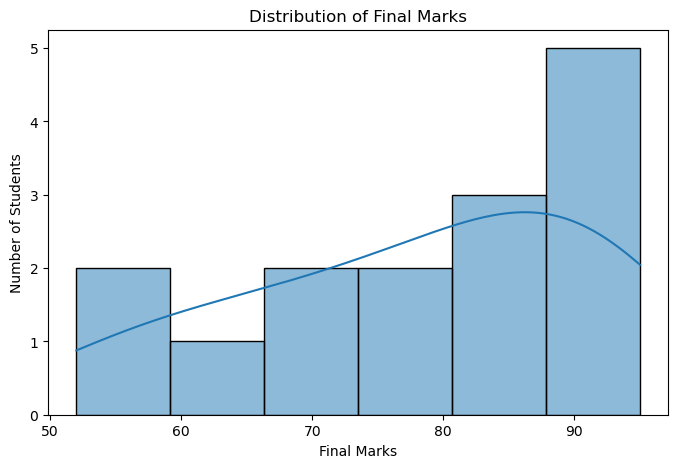

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Final_Marks", bins=6, kde=True)

plt.title("Distribution of Final Marks")
plt.xlabel("Final Marks")
plt.ylabel("Number of Students")

plt.show()

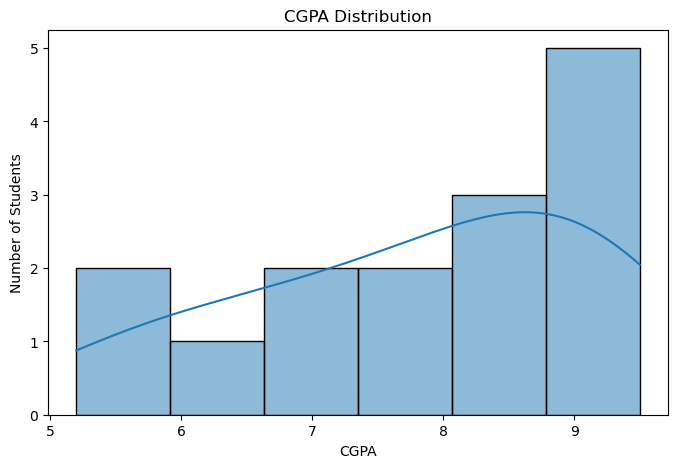

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="CGPA", bins=6, kde=True)

plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")

plt.show()

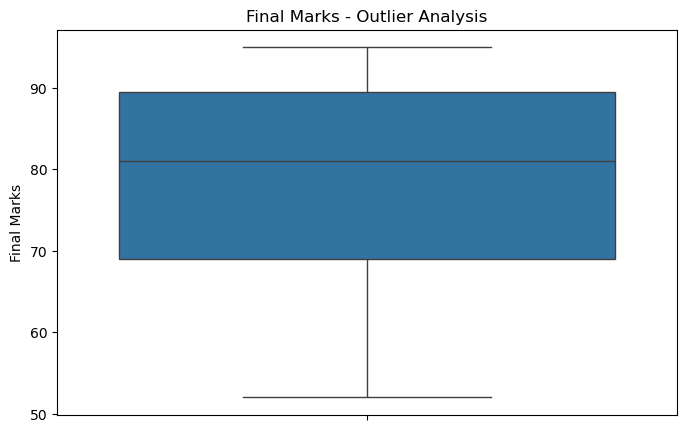

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Final_Marks"])

plt.title("Final Marks - Outlier Analysis")
plt.ylabel("Final Marks")

plt.show()

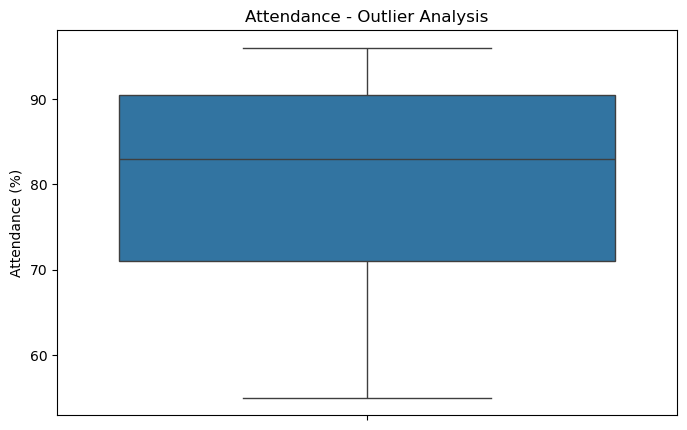

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Attendance"])

plt.title("Attendance - Outlier Analysis")
plt.ylabel("Attendance (%)")

plt.show()

In [24]:
correlation_matrix = df[
    ["Attendance", "Study_Hours", "Assignment_Marks", "Final_Marks", "CGPA"]
].corr()

print(correlation_matrix)

                  Attendance  Study_Hours  Assignment_Marks  Final_Marks  \
Attendance          1.000000     0.955115          0.997006     0.997879   
Study_Hours         0.955115     1.000000          0.956264     0.951862   
Assignment_Marks    0.997006     0.956264          1.000000     0.999245   
Final_Marks         0.997879     0.951862          0.999245     1.000000   
CGPA                0.997879     0.951862          0.999245     1.000000   

                      CGPA  
Attendance        0.997879  
Study_Hours       0.951862  
Assignment_Marks  0.999245  
Final_Marks       1.000000  
CGPA              1.000000  


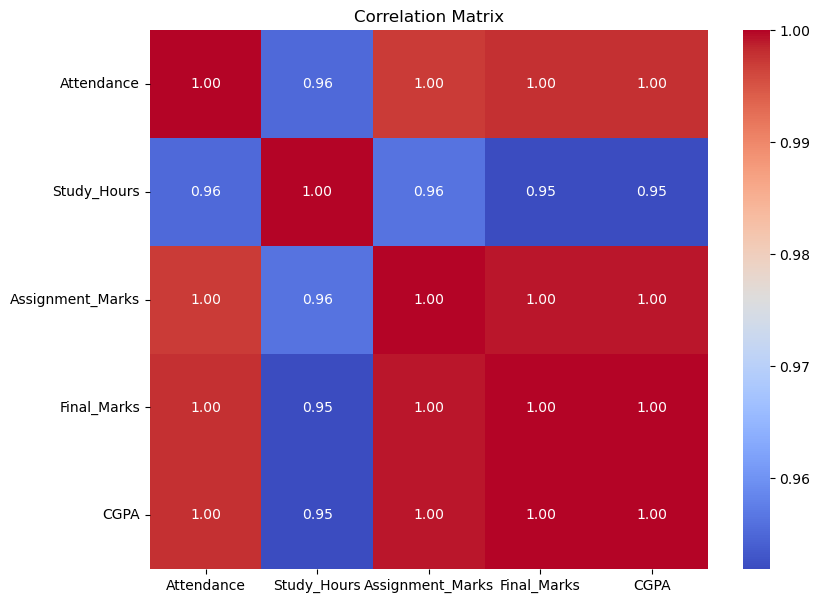

In [25]:
plt.figure(figsize=(9,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [26]:
def performance_category(marks):
    if marks >= 85:
        return "Excellent"
    elif marks >= 70:
        return "Good"
    elif marks >= 60:
        return "Average"
    else:
        return "Needs Improvement"

df["Performance"] = df["Final_Marks"].apply(performance_category)

df[["Student_ID", "Final_Marks", "Performance"]]

,Student_ID,Final_Marks,Performance
0,S001,90,Excellent
1,S002,82,Good
2,S003,75,Good
3,S004,62,Average
4,S005,94,Excellent
5,S006,70,Good
6,S007,87,Excellent
7,S008,52,Needs Improvement
8,S009,91,Excellent
9,S010,78,Good


In [27]:
performance_counts = df["Performance"].value_counts()

print(performance_counts)

Performance
Excellent            6
Good                 5
Average              2
Needs Improvement    2
Name: count, dtype: int64


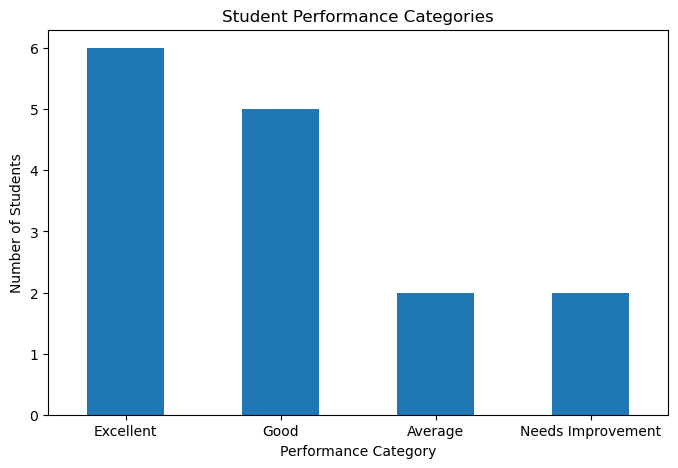

In [28]:
plt.figure(figsize=(8,5))

performance_counts.plot(kind="bar")

plt.title("Student Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.show()

In [29]:
top_students = df.sort_values(by="Final_Marks", ascending=False)

print(top_students[["Student_ID", "Final_Marks", "CGPA"]].head(5))

   Student_ID  Final_Marks  CGPA
11       S012           95   9.5
4        S005           94   9.4
8        S009           91   9.1
0        S001           90   9.0
14       S015           89   8.9


In [30]:
student_needing_improvement = df.loc[df["Final_Marks"].idxmin()]

print("Student Needing Improvement:")
print(student_needing_improvement)

Student Needing Improvement:
Student_ID                       S008
Gender                           Male
Attendance                         55
Study_Hours                         1
Assignment_Marks                   50
Final_Marks                        52
CGPA                              5.2
Performance         Needs Improvement
Name: 7, dtype: object


In [31]:
print("Correlation Results")

print("Attendance:", round(df["Attendance"].corr(df["Final_Marks"]), 2))
print("Study Hours:", round(df["Study_Hours"].corr(df["Final_Marks"]), 2))
print("Assignment Marks:", round(df["Assignment_Marks"].corr(df["Final_Marks"]), 2))
print("CGPA:", round(df["CGPA"].corr(df["Final_Marks"]), 2))

Correlation Results
Attendance: 1.0
Study Hours: 0.95
Assignment Marks: 1.0
CGPA: 1.0


## Key Findings

1. The dataset contains student academic performance information.
2. The dataset was checked for missing values and duplicate records.
3. The average performance of students was calculated using statistical analysis.
4. Attendance was analyzed against final marks.
5. Study hours were analyzed against final marks.
6. Assignment marks were compared with final marks.
7. Gender-wise average performance was analyzed.
8. The distribution of final marks and CGPA was visualized.
9. Boxplots were used to identify potential anomalies.
10. A correlation matrix was created to understand relationships between numerical variables.
11. Students were grouped into different performance categories.
12. Top-performing and low-performing students were identified.


## Conclusion

This project used Exploratory Data Analysis techniques to analyze student academic performance.

The analysis examined attendance, study hours, assignment marks, final marks, and CGPA. Statistical analysis and visualizations were used to identify patterns and relationships within the dataset.

The project also checked the dataset for missing values, duplicate records, and potential anomalies.

The analysis provides useful insights into student performance and can help identify students who may need additional academic support.
